# ASAP8 VIP spike responses during passive Detection of Change — manual longitudinal identities

This notebook contains the **Detection-of-Change analysis only**. Electrophysiological phenotype and synchrony characterization live in the separate ephys notebook.

Detected optical spikes remain the primary output, with dF/F retained for trial-wise validation and subthreshold/compound-event context. Cross-session biological identity is read from each mouse's manually curated `roi_identity_registration.csv`; this notebook performs **no automated image registration or ROI matching**.

Main analyses:
1. spike-detection QC;
2. image-activated, image-suppressed, offset, and ramping motifs;
3. image-identity variability/selectivity;
4. response dynamics across repeated image sequences;
5. change responses relative to matched same-image repeats;
6. omission responses, ramping, and post-omission responses;
7. longitudinal comparisons restricted to manually registered cells.

### ROI QC is optional
All anatomical ROIs remain available to the analysis.

Use:

```python
APPLY_ROI_QC_FILTER = False
```

to analyze **all ROIs regardless of automated voltage QC**. This is the default.

Set it to `True` to require both the processed trace-H5 QC flag and the registrar's `valid_roi` flag to pass.

`excluded=True` is a separate manual annotation and is **always respected**, independent of this QC toggle.

The QC columns remain attached to identity tables in either mode for auditing.


## Depth-color convention

Superficial planes are peach/red and deeper planes are blue. Colors are assigned from the **actual cortical depth in the registry**, rather than from the DMD number, so sessions in which DMD1 and DMD2 were swapped are handled correctly.

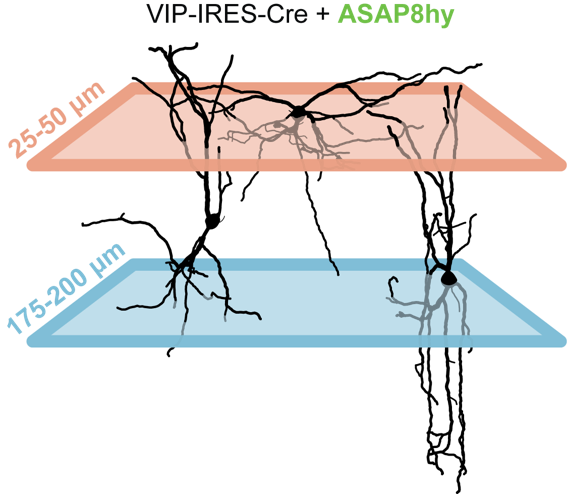

## 0. Imports and publication plotting style

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import json, re, warnings
import os 
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from scipy import ndimage, signal, optimize, stats
from IPython.display import display, HTML

from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.utils.utils import save_figure

display(HTML("<style>.container { width:100% !important; }</style>"))

# PNW-style depth palette: superficial peach -> deep blue.
NAVY = "#1D457F"
CHARCOAL = "#2D2926"
PEACH = "#EBA07E"
DARK_PEACH = "#A8554E"
BLUE = "#5D9FC4"
DARK_BLUE = "#245A78"
TEAL = "#55A6A6"
CREAM = "#FEF7C7"
LIGHT_GRAY = "#D9D9D9"
MID_GRAY = "#777777"
DEPTH_CMAP = LinearSegmentedColormap.from_list("depth_peach_blue", [PEACH, BLUE])

plt.rcParams.update({
    "figure.dpi": 115,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.transparent": False,
    "font.family": "sans-serif",
    "font.size": 10.5,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def save_panel(fig, name):
    if not SAVE_FIGURES:
        return
    for ext in ("png", "pdf", "svg"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", facecolor="white")


## 1. Configuration

In [ ]:
BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")
TARGET_MICE = [852835, 863774]
SELECTED_SESSION_IDS = None  # or an explicit list of session IDs
PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]
TRACE_VARIANT = "dff_robust_f0_trial"
EXPECTED_F0_SMOOTH_SEC = 60.0

OUT_DIR = BASE_PATH / "ASAP8" / "analysis" / "asap8_doc_spike_responses_manual_ids"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
CACHE_DIR = OUT_DIR / "cache"
for path in (OUT_DIR, FIG_DIR, TABLE_DIR, CACHE_DIR):
    path.mkdir(parents=True, exist_ok=True)

SAVE_FIGURES = True
SAVE_TABLES = True
FORCE_SPIKE_RECOMPUTE = False

# Spike detector: same candidate-peak scheme as ASAP8_Somatic_Ephys_Characterization.
DETECTION = {
    "candidate_height_sd": 1.75,
    "prominence_dff": 0.10,
    "prominence_window_ms": 50.0,
    "refractory_ms": 1.0,
    "min_width_ms": 1.0,
    "group_link_ms": 20.0,
    "trial_edge_ms": 2.0,
}

# Statistical/visual response windows in seconds relative to expected image onset.
WINDOWS = {
    "baseline": (-0.25, 0.00),
    "image": (0.00, 0.25),
    "early_blank": (0.25, 0.50),
    "late_blank": (0.50, 0.75),
    "full_cycle": (0.00, 0.75),
}
PSTH_RANGE = (-0.25, 0.75)
PSTH_BIN_MS = 5.0
PSTH_SMOOTH_MS = 15.0  # visualization only; statistics use unsmoothed counts

# Image identity and sequence analysis.
IDENTITY_WINDOW = "image"
CV_FOLDS = 5
CV_REPEATS = 20
N_PERMUTATIONS = 500
MAX_SEQUENCE_POSITION = 8
MIN_TRIALS_PER_IMAGE = 12
MIN_SEQUENCES_PER_POSITION = 8


# Manual longitudinal ROI identity table produced by
# ASAP8_Manual_Longitudinal_ROI_Registration.ipynb.
ROI_REGISTRATION_FILENAME = "roi_identity_registration.csv"
REQUIRE_MANUAL_REGISTRATION_FOR_LONGITUDINAL = True

# Automated voltage-ROI QC is advisory by default. Set True to exclude QC-failing ROIs.
APPLY_ROI_QC_FILTER = True

RNG = np.random.default_rng(84631)
print("Output:", OUT_DIR)


## 2. Resolve sessions and all four voltage products through the registry

In [ ]:
def first_existing(paths):
    for path in paths:
        if path is None:
            continue
        path = Path(path)
        if path.exists():
            return path
    return None


def asset_value(asset, name, default=None):
    value = getattr(asset, name, default)
    return value() if callable(value) else value


def session_label(row):
    image_set = row.get("image_set", np.nan)
    day = row.get("image_set_day_index", np.nan)
    if pd.notna(image_set) and pd.notna(day):
        return f"{image_set}{int(day)}"
    return str(row.get("session_type", row["session_id"]))


def resolve_products(asset):
    voltage_dir = Path(asset.derived_dir) / "voltage"
    qc_dir = Path(asset.qc_dir) / "voltage"
    suffix = TRACE_VARIANT
    qc_json = first_existing([
        qc_dir / f"voltage_extraction_qc_{suffix}.json",
        *sorted(qc_dir.glob("voltage_extraction_qc_*.json")),
    ])
    if qc_json is None:
        raise FileNotFoundError(f"No voltage extraction QC JSON found in {qc_dir}")
    with qc_json.open("r") as f:
        qc = json.load(f)

    metadata = qc.get("metadata", {}) if isinstance(qc.get("metadata", {}), dict) else {}
    summary_value = qc.get("summary_mat", metadata.get("summary_mat"))
    products = {
        "mean_npz": voltage_dir / f"voltage_mean_{suffix}.npz",
        "sequence_npz": voltage_dir / f"voltage_sequence_{suffix}.npz",
        "trace_h5": voltage_dir / f"voltage_session_traces_{suffix}.h5",
        "single_trials": first_existing([
            voltage_dir / f"voltage_single_trial_{suffix}.h5",
            voltage_dir / f"voltage_single_trial_{suffix}.npz",
        ]),
        "qc_json": qc_json,
        "summary_mat": Path(summary_value) if summary_value else None,
        "bonsai_event_log_csv": first_existing([
            asset_value(asset, "bonsai_event_log_csv"),
            qc.get("bonsai_event_log_csv"),
            metadata.get("bonsai_event_log_csv"),
        ]),
        "qc": qc,
    }
    return products


registry = VIPSessionRegistry.from_basepath(BASE_PATH)
sessions_df = registry.sessions(
    subject_ids=TARGET_MICE,
    paradigms=PARADIGMS,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
).copy()

if SELECTED_SESSION_IDS is not None:
    sessions_df = sessions_df[sessions_df["session_id"].astype(str).isin(SELECTED_SESSION_IDS)]

sessions_df["session_datetime"] = pd.to_datetime(
    sessions_df["session_id"].astype(str).str.extract(r"(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})")[0],
    format="%Y-%m-%d_%H-%M-%S", errors="coerce",
)
sessions_df = sessions_df.sort_values(["subject_id", "session_datetime"]).reset_index(drop=True)
sessions_df["session_order"] = sessions_df.groupby("subject_id").cumcount()
sessions_df["session_label"] = sessions_df.apply(session_label, axis=1)

assets = {}
product_rows = []
for _, row in sessions_df.iterrows():
    asset = registry.resolve_assets(row)
    products = resolve_products(asset)
    required = ("mean_npz", "sequence_npz", "trace_h5", "single_trials", "summary_mat", "bonsai_event_log_csv")
    missing = [k for k in required if products.get(k) is None or not Path(products[k]).exists()]
    if missing:
        warnings.warn(f"{asset.session_id}: missing {missing}; session skipped")
        continue

    mean_pkg = np.load(products["mean_npz"], allow_pickle=True)["data"][0]
    meta = mean_pkg.get("metadata", {})
    f0_sec = float(meta.get("robust_f0_smooth_sec", np.nan))
    if not np.isfinite(f0_sec) or not np.isclose(f0_sec, EXPECTED_F0_SMOOTH_SEC):
        warnings.warn(
            f"{asset.session_id}: F0 smoother is {f0_sec!r} s, expected {EXPECTED_F0_SMOOTH_SEC:g} s"
        )

    assets[str(asset.session_id)] = {"asset": asset, "products": products, "row": row.to_dict()}
    product_rows.append({
        "subject_id": asset.subject_id,
        "session_id": str(asset.session_id),
        "session_label": row["session_label"],
        "mean_npz": products["mean_npz"],
        "sequence_npz": products["sequence_npz"],
        "trace_h5": products["trace_h5"],
        "single_trials": products["single_trials"],
        "summary_mat": products["summary_mat"],
        "f0_smooth_sec": f0_sec,
        "timebase_strategy": meta.get("timebase_strategy", meta.get("timebase_strategy_used", "unknown")),
    })

products_df = pd.DataFrame(product_rows)
if products_df.empty:
    raise RuntimeError("No complete ASAP8 sessions were found after registry/product checks.")
display(products_df)


## 3. Compact readers for masks, acquisition geometry, event files, and traces

> **Geometry note (v2):** MATLAB reference images may contain multiple channels or planes. The loader now selects the highest-contrast plane/channel, orients it to the ROI-mask geometry, and validates `[Y, X]` / `[ROI, Y, X]` shapes before registration.


In [ ]:
def load_npz_package(path):
    return np.load(path, allow_pickle=True)["data"][0]


def row_depth(row, dmd):
    for key in (f"dmd{dmd}_depth", f"dmd{dmd}_depth_um", f"DMD{dmd}_depth", f"DMD{dmd}_depth_um"):
        if key in row and pd.notna(row[key]):
            return float(row[key])
    metadata = row.get("metadata", {}) if isinstance(row.get("metadata", {}), dict) else {}
    for key in (f"dmd{dmd}_depth", f"dmd{dmd}_depth_um"):
        if key in metadata and pd.notna(metadata[key]):
            return float(metadata[key])
    raise KeyError(f"No cortical-depth field found for DMD{dmd}")


def source_roi_axis(package, dmd, source_roi):
    """Map a source/full-session ROI index to the kept-ROI axis in NPZ/H5 summaries."""
    dmd_pkg = package[f"DMD{int(dmd)}"]
    roi_ids = decode_strings(dmd_pkg["roi_ids"])
    label = f"DMD{int(dmd)}_ROI{int(source_roi)}"
    hits = np.flatnonzero(roi_ids == label)
    if not len(hits):
        parsed = np.array([int(re.findall(r"\d+", x)[-1]) for x in roi_ids], dtype=int)
        hits = np.flatnonzero(parsed == int(source_roi))
    if not len(hits):
        raise KeyError(f"{label} is absent from the kept ROI axis")
    return int(hits[0])


def decode_strings(values):
    return np.asarray([
        x.decode() if isinstance(x, (bytes, np.bytes_)) else str(x)
        for x in np.asarray(values).reshape(-1)
    ])


def matlab_ref(h5, ref):
    return h5[np.asarray(ref).reshape(-1)[0]]


def h5_numeric_value(h5, obj):
    """Dereference MATLAB v7.3 reference datasets until a numeric array is reached."""
    if isinstance(obj, h5py.Dataset):
        value = obj[()]
    else:
        value = obj
    array = np.asarray(value)
    if array.dtype == h5py.ref_dtype or array.dtype.kind == "O":
        reference = array.reshape(-1)[0]
        if isinstance(reference, h5py.Reference) and reference:
            return h5_numeric_value(h5, h5[reference])
    return np.asarray(array)


def _canonical_mask_stack(raw_masks):
    """Convert MATLAB/HDF5 mask arrays to [ROI, Y, X]."""
    masks = np.asarray(raw_masks, dtype=bool)

    # Remove only redundant singleton dimensions; preserve a singleton ROI axis.
    while masks.ndim > 3 and 1 in masks.shape:
        axis = next(i for i, n in enumerate(masks.shape) if n == 1)
        masks = np.squeeze(masks, axis=axis)
    if masks.ndim == 2:
        masks = masks[None, ...]
    if masks.ndim != 3:
        raise ValueError(f"Expected a 2-D/3-D ROI mask array, got shape {masks.shape}")

    # The ROI dimension is much smaller than either DMD spatial dimension.
    roi_axis = int(np.argmin(masks.shape))
    masks = np.moveaxis(masks, roi_axis, 0)

    # MATLAB v7.3 arrays are read with spatial axes reversed by h5py.
    masks = masks.transpose(0, 2, 1)
    return np.ascontiguousarray(masks, dtype=bool)


def _canonical_reference_image(raw_image, target_shape):
    """Return one high-contrast reference plane/channel as [Y, X]."""
    image = np.asarray(raw_image, dtype=np.float32)
    while image.ndim > 2 and 1 in image.shape:
        image = np.squeeze(image, axis=next(i for i, n in enumerate(image.shape) if n == 1))

    target_shape = tuple(map(int, target_shape))
    candidates = []

    if image.ndim == 2:
        candidates = [image, image.T]
    elif image.ndim >= 3:
        # Find two axes that can represent the mask's spatial dimensions. Any
        # remaining axes are channels, z planes, or singleton metadata axes.
        for ax0 in range(image.ndim):
            for ax1 in range(ax0 + 1, image.ndim):
                pair = (image.shape[ax0], image.shape[ax1])
                if pair not in (target_shape, target_shape[::-1]):
                    continue
                moved = np.moveaxis(image, (ax0, ax1), (-2, -1))
                planes = moved.reshape((-1,) + moved.shape[-2:])
                for plane in planes:
                    candidates.extend([plane, plane.T])
    else:
        raise ValueError(f"Reference image has invalid shape {image.shape}")

    candidates = [np.asarray(x, np.float32) for x in candidates if x.shape == target_shape]
    if not candidates:
        raise ValueError(
            f"Could not orient reference image shape {image.shape} to mask shape {target_shape}"
        )

    # Use the channel/plane with the strongest robust spatial contrast for
    # phase-correlation registration. This avoids averaging a useful structural
    # channel with an empty or weak secondary channel.
    def contrast_score(x):
        finite = x[np.isfinite(x)]
        if not len(finite):
            return -np.inf
        lo, hi = np.percentile(finite, [2, 99.5])
        return float(hi - lo)

    return np.ascontiguousarray(max(candidates, key=contrast_score), dtype=np.float32)


def read_reference_and_masks(summary_path, dmd):
    """Return native DMD image [Y,X] and masks [ROI,Y,X], without display flips."""
    with h5py.File(summary_path, "r") as h5:
        ref_image = matlab_ref(h5, h5["summary/refIM"][int(dmd)-1, 0])
        ref_masks = matlab_ref(h5, h5["summary/masks"][int(dmd)-1, 0])
        masks = _canonical_mask_stack(ref_masks[()])
        image = _canonical_reference_image(ref_image[()], masks.shape[1:])

    if image.ndim != 2 or masks.ndim != 3 or masks.shape[1:] != image.shape:
        raise ValueError(
            f"Invalid image/mask geometry for DMD{dmd}: image={image.shape}, masks={masks.shape}"
        )
    return image, masks


def trace_manifest(trace_h5):
    rows = []
    with h5py.File(trace_h5, "r") as h5:
        for dmd_key in sorted(k for k in h5 if k.startswith("DMD")):
            dmd = int(dmd_key.replace("DMD", ""))
            group = h5[dmd_key]
            roi_ids = decode_strings(group["roi_ids"][:])
            valid = group["valid_rois_mask"][:].astype(bool) if "valid_rois_mask" in group else np.ones(len(roi_ids), bool)
            if len(valid) != len(roi_ids):
                warnings.warn(f"{trace_h5} {dmd_key}: valid_rois_mask length mismatch; treating all ROI IDs as valid")
                valid = np.ones(len(roi_ids), bool)
            timebase = group["timebase_sec"]
            dt = np.nanmedian(np.diff(timebase[: min(len(timebase), 100000)]))
            transform = json.loads(group.attrs.get("signal_transform_json", "{}"))
            for roi, roi_id in enumerate(roi_ids):
                rows.append({
                    "dmd": dmd, "roi": roi, "roi_id": roi_id,
                    "valid_roi": bool(valid[roi]), "sample_rate_hz": 1.0 / dt,
                    "n_samples": int(timebase.shape[0]),
                    "f0_smooth_sec": transform.get("f0_smooth_sec", np.nan),
                })
    return pd.DataFrame(rows)


def corrected_event_table(asset, products):
    event_path = products.get("bonsai_event_log_csv") or asset_value(asset, "bonsai_event_log_csv")
    if event_path is None:
        raise FileNotFoundError(f"No Bonsai event log resolved for {asset.session_id}")
    df = pd.read_csv(event_path)
    time_col = next((c for c in ["corrected_timestamps", "HARP_timestamps", "Timestamp", "timestamp"] if c in df), None)
    if time_col is None:
        raise KeyError(f"No corrected event-time column found in {event_path}")
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
    df["Value"] = df["Value"].fillna("").astype(str).str.strip()
    df = df[df[time_col].notna()].reset_index(names="source_row")

    image_mask = df["Value"].str.lower().str.endswith((".tif", ".tiff")) & ~df["Value"].str.lower().str.contains("photodiode")
    change_mask = df["Value"].str.lower().isin(["change", "changeflash"])
    omission_mask = df["Value"].str.lower().str.contains("omission")
    change_times = df.loc[change_mask, time_col].to_numpy(float)
    omission_times = df.loc[omission_mask, time_col].to_numpy(float)

    rows = []
    pending_change = False
    sequence_id = -1
    expected_position = -1
    actual_position = -1
    previous_image = None
    previous_event_id = None

    for _, source in df.iterrows():
        value = source["Value"]
        lower = value.lower()
        if lower in ("change", "changeflash"):
            pending_change = True
            continue
        if not (lower.endswith(".tif") or lower.endswith(".tiff")) or "photodiode" in lower:
            continue

        onset = float(source[time_col])
        is_omission = bool(np.any(np.isclose(omission_times, onset, atol=1e-3)))
        is_change = bool(pending_change or np.any(np.isclose(change_times, onset, atol=1e-3)))
        pending_change = False
        if is_change:
            sequence_id += 1
            expected_position = 0
            actual_position = 0 if not is_omission else -1
        else:
            expected_position += 1
            if not is_omission:
                actual_position += 1

        event_id = len(rows)
        rows.append({
            "event_id": event_id,
            "source_row": int(source["source_row"]),
            "onset_sec": onset,
            "image_name": value,
            "image_label": Path(value.replace("\\", "/")).stem,
            "is_change": is_change,
            "is_omission": is_omission,
            "sequence_id": sequence_id,
            "sequence_position_expected": expected_position,
            "sequence_position_actual": actual_position if not is_omission else np.nan,
            "previous_image": previous_image,
            "previous_event_id": previous_event_id,
        })
        previous_image = value
        previous_event_id = event_id

    events = pd.DataFrame(rows)
    events["next_event_id"] = events["event_id"].shift(-1)
    events["next_image"] = events["image_name"].shift(-1)
    events["session_time_min"] = (events["onset_sec"] - events["onset_sec"].min()) / 60
    events["time_block"] = np.floor(events["session_time_min"]).astype(int)
    return events


def single_trial_onsets(path):
    """Onsets actually retained by extraction; supports current H5 and legacy NPZ."""
    path = Path(path)
    out = {"image": [], "change": [], "omission": []}
    if path.suffix.lower() == ".h5":
        with h5py.File(path, "r") as h5:
            dmd_key = next(k for k in h5 if k.startswith("DMD"))
            group = h5[dmd_key]
            if "image_identity" in group:
                for key in group["image_identity"]:
                    out["image"].extend(group["image_identity"][key]["onsets_sec"][:].tolist())
            for event in ("change", "omission"):
                if event in group and "onsets_sec" in group[event]:
                    out[event] = group[event]["onsets_sec"][:].tolist()
    else:
        pkg = load_npz_package(path)
        for dmd_key in [k for k in pkg if str(k).startswith("DMD")]:
            dmd_pkg = pkg[dmd_key]
            for image_name, image_data in dmd_pkg.get("image_identity", {}).items():
                out["image"].extend(np.asarray(image_data.get("onsets_sec", [])).tolist())
            for event in ("change", "omission"):
                out[event].extend(np.asarray(dmd_pkg.get(event, {}).get("onsets_sec", [])).tolist())
            break
    return {k: np.unique(np.asarray(v, dtype=float)) for k, v in out.items()}


## 4. Load lightweight session metadata, masks, mean packages, sequence packages, and valid events

In [ ]:
session_data = {}
plane_rows = []
roi_rows = []

for session_id, item in assets.items():
    asset = item["asset"]
    row = item["row"]
    products = item["products"]
    mean_pkg = load_npz_package(products["mean_npz"])
    sequence_pkg = load_npz_package(products["sequence_npz"])
    trace_df = trace_manifest(products["trace_h5"])
    retained = single_trial_onsets(products["single_trials"])
    events = corrected_event_table(asset, products)
    for event_name, retained_times in retained.items():
        events[f"retained_{event_name}_window"] = events["onset_sec"].map(
            lambda t, times=retained_times: bool(np.any(np.isclose(times, t, atol=1e-3)))
        )
    events = events[events["retained_image_window"]].reset_index(drop=True)

    planes = {}
    for dmd in sorted(trace_df["dmd"].unique()):
        depth = row_depth(row, dmd)
        image, masks = read_reference_and_masks(products["summary_mat"], dmd)
        dmd_manifest = trace_df[trace_df["dmd"].eq(dmd)].set_index("roi")
        valid = np.array([
            bool(dmd_manifest.loc[roi, "valid_roi"]) if roi in dmd_manifest.index else False
            for roi in range(len(masks))
        ])
        planes[dmd] = {"depth_um": depth, "image": image, "masks": masks, "valid_rois": valid}
        depth_bin_start = int(np.floor(depth / 100.0) * 10.0)
        plane_rows.append({
            "subject_id": str(asset.subject_id), "session_id": session_id,
            "session_order": row["session_order"], "session_label": row["session_label"],
            "dmd": dmd, "depth_um": depth, "depth_bin_50um": f"{depth_bin_start}–{depth_bin_start+50}",
            "n_rois": len(masks), "n_valid_rois": int(valid.sum()),
        })
        for roi, mask in enumerate(masks):
            yy, xx = np.nonzero(mask)
            roi_rows.append({
                "subject_id": str(asset.subject_id), "session_id": session_id,
                "session_order": row["session_order"], "session_label": row["session_label"],
                "dmd": dmd, "roi": roi, "depth_um": depth,
                "depth_bin_50um": f"{depth_bin_start}–{depth_bin_start+50}",
                "valid_roi": bool(valid[roi]), "roi_area_px": int(mask.sum()),
                "centroid_x_px": float(np.mean(xx)), "centroid_y_px": float(np.mean(yy)),
                "source_roi_label": f"DMD{dmd}_ROI{roi}",
            })

    session_data[session_id] = {
        "asset": asset, "row": row, "products": products,
        "mean": mean_pkg, "sequence": sequence_pkg,
        "trace_manifest": trace_df, "events": events, "planes": planes,
    }

plane_df = pd.DataFrame(plane_rows)
roi_manifest = pd.DataFrame(roi_rows)
depth_limits = (float(plane_df["depth_um"].min()), float(plane_df["depth_um"].max()))
depth_norm = Normalize(*depth_limits)
def depth_color(depth_um):
    return PEACH if float(depth_um) < 100 else BLUE

display(plane_df)
display(roi_manifest.head())


# Part I — Load manually curated longitudinal ROI identities

The manual registration CSV is the only source of biological identity across days. Unassigned ROIs still participate in all single-session DoC analyses using a temporary session-specific ID, but they are excluded from longitudinal same-cell comparisons.


In [ ]:
def _boolish(value, default=False):
    if pd.isna(value):
        return bool(default)
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    return str(value).strip().lower() in {"true", "1", "yes", "y"}


def load_subject_registration(asset):
    path = Path(asset.session_dir).parent / ROI_REGISTRATION_FILENAME
    if not path.exists():
        warnings.warn(
            f"No manual ROI registration table found at {path}. Single-session DoC analyses will run, "
            "but longitudinal identity is unavailable for this mouse."
        )
        return pd.DataFrame(columns=[
            "session_id", "dmd", "roi", "global_cell_id", "valid_roi",
            "excluded", "confidence", "notes"
        ]), path

    table = pd.read_csv(
        path, dtype={"subject_id": str, "session_id": str, "global_cell_id": str}
    )
    for column, default in [
        ("global_cell_id", ""),
        ("valid_roi", True),
        ("excluded", False),
        ("confidence", ""),
        ("notes", ""),
    ]:
        if column not in table:
            if column == "valid_roi":
                warnings.warn(
                    f"{path} has no valid_roi column; treating manual validity as True "
                    "and relying on the processed trace H5 validity mask."
                )
            table[column] = default

    table["global_cell_id"] = table["global_cell_id"].fillna("").replace("nan", "")
    table["valid_roi"] = table["valid_roi"].map(lambda x: _boolish(x, default=True)).astype(bool)
    table["excluded"] = table["excluded"].map(lambda x: _boolish(x, default=False)).astype(bool)
    return table, path


registration_tables = []
registration_paths = {}
subject_assets = {}
for session_id, item in assets.items():
    subject_assets.setdefault(str(item["asset"].subject_id), item["asset"])

for subject_id, asset in subject_assets.items():
    table, path = load_subject_registration(asset)
    registration_paths[str(subject_id)] = path
    if len(table):
        registration_tables.append(table)

manual_registration_df = (
    pd.concat(registration_tables, ignore_index=True)
    if registration_tables else pd.DataFrame()
)

# Start from every anatomical ROI. The trace-manifest QC and manual registration QC
# are then kept as separate columns before constructing the analysis inclusion mask.
identity = roi_manifest.rename(columns={"valid_roi": "trace_h5_valid_roi"}).copy()

if len(manual_registration_df):
    keep_cols = [
        c for c in [
            "session_id", "dmd", "roi", "global_cell_id", "valid_roi",
            "excluded", "confidence", "notes"
        ]
        if c in manual_registration_df
    ]
    manual_for_merge = (
        manual_registration_df[keep_cols]
        .drop_duplicates(["session_id", "dmd", "roi"], keep="last")
        .rename(columns={"valid_roi": "registration_valid_roi"})
    )
    identity = identity.merge(
        manual_for_merge,
        on=["session_id", "dmd", "roi"], how="left",
    )
else:
    identity["global_cell_id"] = ""
    identity["registration_valid_roi"] = True
    identity["excluded"] = False
    identity["confidence"] = ""
    identity["notes"] = ""

identity["global_cell_id"] = identity["global_cell_id"].fillna("").replace("nan", "")
identity["registration_valid_roi"] = (
    identity["registration_valid_roi"].fillna(True)
    .map(lambda x: _boolish(x, default=True)).astype(bool)
)
identity["excluded"] = (
    identity["excluded"].fillna(False)
    .map(lambda x: _boolish(x, default=False)).astype(bool)
)
identity["trace_h5_valid_roi"] = identity["trace_h5_valid_roi"].astype(bool)

identity["valid_roi"] = (
    identity["trace_h5_valid_roi"] & identity["registration_valid_roi"]
)
identity["qc_pass"] = identity["valid_roi"]
identity["analysis_included"] = (~identity["excluded"]) & (
    (~APPLY_ROI_QC_FILTER) | identity["qc_pass"]
)
identity["exclusion_reason"] = np.select(
    [
        identity["excluded"],
        APPLY_ROI_QC_FILTER & ~identity["trace_h5_valid_roi"],
        APPLY_ROI_QC_FILTER & ~identity["registration_valid_roi"],
    ],
    [
        "manual_excluded",
        "trace_h5_qc_fail",
        "registration_csv_qc_fail",
    ],
    default="",
)
identity["manually_registered"] = identity["global_cell_id"].astype(str).ne("")
identity["cell_id"] = identity.apply(
    lambda r: r["global_cell_id"] if r["manually_registered"]
    else f"{r['subject_id']}_{r['session_id']}_DMD{int(r['dmd'])}_ROI{int(r['roi'])}",
    axis=1,
)
identity["assignment_source"] = np.where(
    identity["manually_registered"], "manual", "session_specific"
)
identity["match_score"] = np.where(identity["manually_registered"], 1.0, np.nan)
identity["review_required"] = False
identity["possible_split_merge"] = False

# Save the complete identity/QC table, including anatomically registered QC failures.
roi_identity_all_df = identity.sort_values(
    ["subject_id", "session_order", "dmd", "roi"]
).reset_index(drop=True)
roi_identity_all_df.to_csv(TABLE_DIR / "roi_identities_all_with_qc.csv", index=False)

# This identity table follows the current inclusion rule; QC failures remain included when the toggle is off.
roi_identity_df = roi_identity_all_df[
    roi_identity_all_df["analysis_included"]
].copy().reset_index(drop=True)

# Hard validation of biological identity among observations admitted by the current inclusion rule.
manual_only = roi_identity_df[roi_identity_df["manually_registered"]]
dup = manual_only.duplicated(
    ["subject_id", "session_id", "global_cell_id"], keep=False
)
if dup.any():
    display(
        manual_only.loc[dup]
        .sort_values(["subject_id", "session_id", "global_cell_id"])
    )
    raise ValueError(
        "Manual registration table contains a global_cell_id more than once within a session. "
        "Fix it in the registrar before continuing."
    )

roi_identity_df.to_csv(TABLE_DIR / "roi_identities_used.csv", index=False)

print("Manual registration files:")
for subject_id, path in registration_paths.items():
    print(f"  {subject_id}: {path}")

qc_counts = (
    roi_identity_all_df.groupby(["analysis_included", "exclusion_reason"], dropna=False)
    .size().rename("n_roi_observations").reset_index()
)
display(qc_counts)
print(
    f"DoC analysis inclusion: {int(roi_identity_all_df['analysis_included'].sum())} / "
    f"{len(roi_identity_all_df)} anatomical ROI observations enter physiology "
    f"(APPLY_ROI_QC_FILTER={APPLY_ROI_QC_FILTER})."
)
print(
    f"Manually registered included observations: "
    f"{roi_identity_df['manually_registered'].sum()} / {len(roi_identity_df)}"
)

display(
    manual_only.assign(present=1).pivot_table(
        index=["subject_id", "global_cell_id"],
        columns="session_label",
        values="present",
        aggfunc="max",
        fill_value=0,
    )
    if len(manual_only) else manual_only
)


# Part II — Detect spikes from the full-session dF/F traces

The detector follows the candidate-peak method already validated visually in the ASAP8 electrophysiology notebook. Detection is performed separately within acquisition epochs; peaks near artificial trial-concatenation boundaries are excluded. The output is cached, because reading and searching every full-session ROI trace is the slowest step in this notebook.

Threshold sensitivity and waveform overlays must be reviewed for every new animal or major change in expression/SNR.

**QC rule:** spike detection/loading is restricted to `roi_identity_df`, which contains valid, non-excluded ROI observations only. Stale cached spike rows for invalid ROIs are removed by an inner merge before any response analysis.

## 8. Spike detector and cache

In [ ]:
def contiguous_runs(labels):
    labels = np.asarray(labels)
    changes = np.flatnonzero(np.diff(labels) != 0) + 1
    starts = np.r_[0, changes]
    stops = np.r_[changes, len(labels)]
    return [(a, b, labels[a]) for a, b in zip(starts, stops) if labels[a] > 0]


def detect_spikes(y, fs, sample_epoch=None, trial_lengths=None):
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(y)
    if not finite.all():
        y = np.interp(np.arange(len(y)), np.flatnonzero(finite), y[finite])
    segments = [(0, len(y), 1)] if sample_epoch is None else contiguous_runs(sample_epoch)
    peaks_all, threshold_rows = [], []

    prominence_wlen = max(3, int(round(DETECTION["prominence_window_ms"] / 1000 * fs)))
    prominence_wlen += 1 - prominence_wlen % 2
    distance = max(1, int(round(DETECTION["refractory_ms"] / 1000 * fs)))
    min_width = max(1.0, DETECTION["min_width_ms"] / 1000 * fs)

    for start, stop, epoch in segments:
        segment = y[start:stop]
        center = float(np.mean(segment))
        scale = float(np.std(segment, ddof=1))
        threshold = center + DETECTION["candidate_height_sd"] * scale
        peaks, properties = signal.find_peaks(
            segment, height=threshold, prominence=DETECTION["prominence_dff"],
            distance=distance, width=min_width, wlen=prominence_wlen,
        )
        peaks_all.extend((peaks + start).tolist())
        threshold_rows.append({"epoch": int(epoch), "start": start, "stop": stop,
                               "center": center, "scale": scale, "threshold": threshold})

    peaks = np.asarray(sorted(peaks_all), dtype=np.int64)
    if trial_lengths is not None and DETECTION["trial_edge_ms"] > 0 and len(peaks):
        edges = np.cumsum(np.asarray(trial_lengths, dtype=int))[:-1]
        edge = int(round(DETECTION["trial_edge_ms"] / 1000 * fs))
        keep = np.ones(len(peaks), dtype=bool)
        for boundary in edges:
            keep &= np.abs(peaks - boundary) > edge
        peaks = peaks[keep]

    # Group closely spaced peaks without changing the individual spike times.
    classes = np.full(len(peaks), "singleton", dtype=object)
    event_id = np.arange(len(peaks), dtype=int)
    if len(peaks):
        splits = np.r_[0, np.flatnonzero(np.diff(peaks) > DETECTION["group_link_ms"] / 1000 * fs) + 1, len(peaks)]
        for eid, (a, b) in enumerate(zip(splits[:-1], splits[1:])):
            event_id[a:b] = eid
            classes[a:b] = "singleton" if b-a == 1 else ("doublet" if b-a == 2 else "burst")
    return peaks, classes, event_id, pd.DataFrame(threshold_rows)


def detect_session_spikes(session_id, item, allowed_rois_by_dmd=None):
    qc_mode = "qcfiltered" if APPLY_ROI_QC_FILTER else "allrois"
    cache_path = CACHE_DIR / f"{session_id}_spike_times_{qc_mode}.npz"
    threshold_path = CACHE_DIR / f"{session_id}_detection_thresholds_{qc_mode}.csv"
    if cache_path.exists() and not FORCE_SPIKE_RECOMPUTE:
        cached = np.load(cache_path, allow_pickle=True)
        rows = []
        for key in cached.files:
            if not key.endswith("_times"):
                continue
            prefix = key[:-6]
            dmd, roi = map(int, re.findall(r"\d+", prefix))
            times = cached[key]
            classes = cached[prefix + "_classes"]
            events = cached[prefix + "_events"]
            allowed = None if allowed_rois_by_dmd is None else allowed_rois_by_dmd.get(int(dmd), set())
            if allowed is not None and int(roi) not in allowed:
                continue
            for t, cls, eid in zip(times, classes, events):
                rows.append({"session_id": session_id, "dmd": dmd, "roi": roi,
                             "spike_time_sec": float(t), "spike_class": str(cls), "spike_event_id": int(eid)})
        return pd.DataFrame(rows)

    arrays, rows, threshold_rows = {}, [], []
    trace_h5 = item["products"]["trace_h5"]
    with h5py.File(trace_h5, "r") as h5:
        for dmd_key in sorted(k for k in h5 if k.startswith("DMD")):
            dmd = int(dmd_key.replace("DMD", ""))
            group = h5[dmd_key]
            timebase = group["timebase_sec"][:]
            fs = 1.0 / np.nanmedian(np.diff(timebase[: min(len(timebase), 100000)]))
            sample_epoch = group["sample_epoch"][:] if "sample_epoch" in group else None
            trial_lengths = group["trial_lengths_samples"][:] if "trial_lengths_samples" in group else None
            valid = (
                group["valid_rois_mask"][:].astype(bool)
                if "valid_rois_mask" in group else np.ones(group["dff"].shape[0], bool)
            )
            allowed = None if allowed_rois_by_dmd is None else allowed_rois_by_dmd.get(int(dmd), set())
            roi_indices = np.where(valid)[0] if APPLY_ROI_QC_FILTER else np.arange(group["dff"].shape[0])
            for roi in roi_indices:
                if allowed is not None and int(roi) not in allowed:
                    continue
                y = group["dff"][int(roi), :]
                peaks, classes, event_ids, thresholds = detect_spikes(
                    y, fs, sample_epoch=sample_epoch, trial_lengths=trial_lengths,
                )
                prefix = f"DMD{dmd}_ROI{roi}"
                arrays[prefix + "_times"] = timebase[peaks]
                arrays[prefix + "_classes"] = classes.astype("U12")
                arrays[prefix + "_events"] = event_ids
                thresholds["session_id"] = session_id
                thresholds["dmd"] = dmd
                thresholds["roi"] = roi
                threshold_rows.append(thresholds)
                for t, cls, eid in zip(timebase[peaks], classes, event_ids):
                    rows.append({"session_id": session_id, "dmd": dmd, "roi": int(roi),
                                 "spike_time_sec": float(t), "spike_class": str(cls), "spike_event_id": int(eid)})
    np.savez_compressed(cache_path, **arrays)
    if threshold_rows:
        pd.concat(threshold_rows, ignore_index=True).to_csv(threshold_path, index=False)
    else:
        pd.DataFrame(columns=["session_id", "dmd", "roi"]).to_csv(threshold_path, index=False)
    return pd.DataFrame(rows)


allowed_roi_lookup = {}
for session_id, sub in roi_identity_df.groupby("session_id"):
    allowed_roi_lookup[str(session_id)] = {
        int(dmd): set(g["roi"].astype(int))
        for dmd, g in sub.groupby("dmd")
    }

spike_tables = []
for session_id, item in session_data.items():
    print("Detecting/loading", session_id)
    spike_tables.append(
        detect_session_spikes(
            session_id,
            item,
            allowed_rois_by_dmd=allowed_roi_lookup.get(str(session_id), {}),
        )
    )

nonempty_spike_tables = [x for x in spike_tables if len(x)]
spike_df = (
    pd.concat(nonempty_spike_tables, ignore_index=True)
    if nonempty_spike_tables
    else pd.DataFrame(columns=["session_id", "dmd", "roi", "spike_time_sec", "spike_class", "spike_event_id"])
)

# Inner merge applies the current analysis-inclusion table. Cache filenames are QC-mode-specific,
# so toggling QC cannot silently reuse a cache that omitted QC-failing ROIs.
spike_df = spike_df.merge(
    roi_identity_df[[
        "session_id", "dmd", "roi", "subject_id", "session_label", "depth_um",
        "cell_id", "global_cell_id", "manually_registered"
    ]],
    on=["session_id", "dmd", "roi"], how="inner",
)
spike_df.to_csv(TABLE_DIR / "detected_spikes.csv.gz", index=False, compression="gzip")
display(spike_df.groupby(["session_id", "dmd", "roi"]).size().rename("n_spikes").reset_index())


## 9. Detection QC: full-trace rate, threshold overlay, and isolated waveforms

In [ ]:
# Edit these after inspecting the ROI manifest.
QC_SESSION = products_df.iloc[0]["session_id"]
QC_DMD = int(roi_identity_df[roi_identity_df["session_id"].eq(QC_SESSION)].iloc[0]["dmd"])
QC_ROI = int(roi_identity_df[
    roi_identity_df["session_id"].eq(QC_SESSION) & roi_identity_df["dmd"].eq(QC_DMD)
].iloc[0]["roi"])
QC_WINDOW_SEC = (20.0, 25.0)

item = session_data[QC_SESSION]
with h5py.File(item["products"]["trace_h5"], "r") as h5:
    group = h5[f"DMD{QC_DMD}"]
    timebase = group["timebase_sec"][:]
    y = group["dff"][QC_ROI, :]
    fs = 1.0 / np.nanmedian(np.diff(timebase[:100000]))

roi_spikes = spike_df[
    spike_df["session_id"].eq(QC_SESSION) & spike_df["dmd"].eq(QC_DMD) & spike_df["roi"].eq(QC_ROI)
]["spike_time_sec"].to_numpy()
q0, q1 = QC_WINDOW_SEC
mask = (timebase >= q0) & (timebase <= q1)
peaks = roi_spikes[(roi_spikes >= q0) & (roi_spikes <= q1)]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={"height_ratios": [2.1, 1]})
axes[0].plot(timebase[mask], y[mask], color=CHARCOAL, lw=0.65)
axes[0].scatter(peaks, np.interp(peaks, timebase, y), marker="v", s=28,
                color=depth_color(item["planes"][QC_DMD]["depth_um"]), zorder=3)
axes[0].set_ylabel("dF/F")
axes[0].set_title(f"{QC_SESSION} · DMD{QC_DMD} ROI{QC_ROI}: detected optical spikes")

# Detected-peak waveforms for detector sanity checking; use the ephys notebook for isolated-singleton morphology.
pre, post = int(round(0.010 * fs)), int(round(0.020 * fs))
waveforms = []
indices = np.searchsorted(timebase, roi_spikes)
for index in indices:
    if index-pre >= 0 and index+post < len(y):
        w = y[index-pre:index+post+1].copy()
        w -= np.median(w[: max(3, pre//2)])
        waveforms.append(w)
waveforms = np.asarray(waveforms[:500])
t_ms = (np.arange(pre+post+1) - pre) / fs * 1000
if len(waveforms):
    lo, med, hi = np.percentile(waveforms, [10, 50, 90], axis=0)
    color = depth_color(item["planes"][QC_DMD]["depth_um"])
    axes[1].fill_between(t_ms, lo, hi, color=color, alpha=0.22, lw=0)
    axes[1].plot(t_ms, med, color=color, lw=2)
axes[1].axvline(0, color=LIGHT_GRAY, lw=1)
axes[1].set(xlabel="Time from detected peak (ms)", ylabel="Baseline-subtracted dF/F")
fig.tight_layout()
save_panel(fig, "02_spike_detection_qc")
plt.show()


# Part III — Build the trial-level spike-response table

All inferential quantities below are computed from unsmoothed spike counts. The 15 ms Gaussian PSTH is used only for visualization.

Ordinary image analyses exclude change targets and omission positions. Change analyses compare each change with temporally nearby, same-image repeats. Omission analyses retain the nominal expected image identity from the Bonsai sequence and compare the omitted cycle with matched ordinary cycles.

## 10. Count spikes in event windows

In [ ]:
def count_spikes(spike_times, onsets, start, stop):
    spike_times = np.asarray(spike_times, float)
    onsets = np.asarray(onsets, float)
    return np.searchsorted(spike_times, onsets + stop, side="left") - np.searchsorted(spike_times, onsets + start, side="left")


def first_spike_latency(spike_times, onsets, start=0.0, stop=0.25):
    spike_times = np.asarray(spike_times, float)
    out = np.full(len(onsets), np.nan)
    left = np.searchsorted(spike_times, np.asarray(onsets) + start, side="left")
    for i, (onset, j) in enumerate(zip(onsets, left)):
        if j < len(spike_times) and spike_times[j] < onset + stop:
            out[i] = spike_times[j] - onset
    return out


event_response_rows = []
for session_id, item in session_data.items():
    events = item["events"].copy()
    identities = roi_identity_df[roi_identity_df["session_id"].eq(session_id)]
    for _, identity in identities.iterrows():
        spikes = spike_df[
            spike_df["session_id"].eq(session_id)
            & spike_df["dmd"].eq(identity.dmd)
            & spike_df["roi"].eq(identity.roi)
        ]["spike_time_sec"].to_numpy()
        table = events.copy()
        for name, (start, stop) in WINDOWS.items():
            table[f"{name}_count"] = count_spikes(spikes, table["onset_sec"], start, stop)
            table[f"{name}_rate_hz"] = table[f"{name}_count"] / (stop - start)
        table["first_spike_latency_ms"] = 1000 * first_spike_latency(spikes, table["onset_sec"])
        table["spike_probability"] = table["image_count"].gt(0).astype(float)
        table["burst_probability"] = table["image_count"].ge(2).astype(float)
        table["image_delta_hz"] = table["image_rate_hz"] - table["baseline_rate_hz"]
        table["offset_delta_hz"] = table["early_blank_rate_hz"] - table["baseline_rate_hz"]
        table["late_ramp_hz"] = table["late_blank_rate_hz"] - table["early_blank_rate_hz"]
        table["subject_id"] = identity.subject_id
        table["session_id"] = session_id
        table["session_label"] = identity.session_label
        table["session_order"] = int(identity.session_order)
        table["dmd"] = int(identity.dmd)
        table["roi"] = int(identity.roi)
        table["cell_id"] = identity.cell_id
        table["depth_um"] = identity.depth_um
        event_response_rows.append(table)

event_response_df = pd.concat(event_response_rows, ignore_index=True)
event_response_df.to_csv(TABLE_DIR / "event_level_spike_responses.csv.gz", index=False, compression="gzip")
display(event_response_df.head())


## 11. Statistical helpers: blockwise paired tests, FDR, PSTH, and image-identity deviance

In [ ]:
def signflip_p(values, n_perm=10000, rng=RNG):
    values = np.asarray(values, float)
    values = values[np.isfinite(values)]
    if len(values) < 3:
        return np.nan
    observed = abs(values.mean())
    signs = rng.choice([-1, 1], size=(n_perm, len(values)))
    null = np.abs((signs * values).mean(axis=1))
    return (1 + np.sum(null >= observed)) / (n_perm + 1)


def blockwise_p(table, value_col, block_col="time_block"):
    block_means = table.groupby(block_col)[value_col].mean().to_numpy()
    return signflip_p(block_means)


def fdr_bh(pvalues):
    p = np.asarray(pvalues, float)
    q = np.full(len(p), np.nan)
    finite = np.flatnonzero(np.isfinite(p))
    if not len(finite):
        return q
    order = finite[np.argsort(p[finite])]
    ranked = p[order] * len(order) / np.arange(1, len(order)+1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    q[order] = np.clip(ranked, 0, 1)
    return q


def psth(spike_times, onsets, window=PSTH_RANGE, bin_ms=PSTH_BIN_MS, smooth_ms=PSTH_SMOOTH_MS):
    edges = np.arange(window[0], window[1] + bin_ms/1000, bin_ms/1000)
    counts = np.zeros(len(edges)-1)
    for onset in np.asarray(onsets, float):
        relative = spike_times[(spike_times >= onset+window[0]) & (spike_times < onset+window[1])] - onset
        counts += np.histogram(relative, edges)[0]
    rate = counts / max(len(onsets), 1) / (bin_ms/1000)
    if smooth_ms > 0:
        rate = ndimage.gaussian_filter1d(rate, sigma=smooth_ms/bin_ms, mode="nearest")
    return (edges[:-1] + edges[1:]) / 2, rate


def poisson_deviance(y, mu):
    y = np.asarray(y, float)
    mu = np.clip(np.asarray(mu, float), 1e-6, None)
    with np.errstate(divide="ignore", invalid="ignore"):
        term = np.where(y > 0, y * np.log(y / mu), 0.0)
    return 2 * np.sum(term - (y - mu))


def image_identity_metrics(table, response_col, n_folds=CV_FOLDS, repeats=CV_REPEATS, rng=RNG):
    """Image coding with descriptive FVE and time-block-protected inference.

    Labels are permuted within one-minute blocks, and cross-validation holds out
    whole time blocks, reducing false image selectivity from bleaching, adaptation,
    or other slow nonstationarity.
    """
    table = table[["image_label", response_col, "time_block"]].dropna().copy()
    counts = table["image_label"].value_counts()
    keep = counts[counts >= MIN_TRIALS_PER_IMAGE].index
    table = table[table["image_label"].isin(keep)].reset_index(drop=True)
    if table["image_label"].nunique() < 2:
        return {
            "image_rms_hz": np.nan, "image_fve": np.nan, "image_cv_deviance": np.nan,
            "image_identity_p": np.nan, "preferred_image": None,
            "n_images": int(table["image_label"].nunique()),
        }

    y = table[response_col].to_numpy(float)
    labels = table["image_label"].to_numpy()
    blocks = table["time_block"].to_numpy()
    means = table.groupby("image_label")[response_col].mean()
    grand = y.mean()
    window_duration = WINDOWS[IDENTITY_WINDOW][1] - WINDOWS[IDENTITY_WINDOW][0]
    rms = float(np.sqrt(np.mean((means - grand) ** 2)) / window_duration)
    total_ss = np.sum((y - grand) ** 2)
    between_ss = sum(np.sum(labels == label) * (mean - grand) ** 2 for label, mean in means.items())
    fve = float(between_ss / total_ss) if total_ss > 0 else np.nan

    null_fve = np.empty(N_PERMUTATIONS, float)
    unique_blocks = np.unique(blocks)
    for permutation in range(N_PERMUTATIONS):
        shuffled = labels.copy()
        for block in unique_blocks:
            idx = np.flatnonzero(blocks == block)
            shuffled[idx] = rng.permutation(shuffled[idx])
        shuffled_means = {label: y[shuffled == label].mean() for label in np.unique(shuffled)}
        null_between = sum(np.sum(shuffled == label) * (mean - grand) ** 2
                           for label, mean in shuffled_means.items())
        null_fve[permutation] = null_between / total_ss if total_ss > 0 else np.nan
    image_p = (1 + np.sum(null_fve >= fve)) / (N_PERMUTATIONS + 1) if np.isfinite(fve) else np.nan

    scores = []
    effective_folds = min(n_folds, len(unique_blocks))
    if effective_folds >= 2:
        for _ in range(repeats):
            shuffled_blocks = rng.permutation(unique_blocks)
            block_to_fold = {block: i % effective_folds for i, block in enumerate(shuffled_blocks)}
            folds = np.array([block_to_fold[block] for block in blocks])
            for fold in range(effective_folds):
                train, test = folds != fold, folds == fold
                if not test.any() or not train.any():
                    continue
                train_means = pd.Series(y[train]).groupby(labels[train]).mean().to_dict()
                mu_image = np.array([train_means.get(label, y[train].mean()) for label in labels[test]])
                mu_null = np.full(test.sum(), y[train].mean())
                d_null = poisson_deviance(y[test], mu_null)
                if d_null > 0:
                    scores.append(1 - poisson_deviance(y[test], mu_image) / d_null)
    return {
        "image_rms_hz": rms,
        "image_fve": fve,
        "image_cv_deviance": float(np.mean(scores)) if scores else np.nan,
        "image_identity_p": float(image_p),
        "preferred_image": str(means.idxmax()),
        "n_images": int(len(means)),
    }


# Part IV — Image response motifs and image-identity coding

## 12. Quantify image/offset/ramping motifs per ROI

In [ ]:
ordinary = event_response_df[~event_response_df["is_change"] & ~event_response_df["is_omission"]].copy()

response_rows = []
identity_keys = ["subject_id", "session_id", "session_label", "session_order", "dmd", "roi", "cell_id", "depth_um"]
for keys, table in ordinary.groupby(identity_keys):
    row = dict(zip(identity_keys, keys))
    row.update({
        "baseline_rate_hz": table["baseline_rate_hz"].mean(),
        "image_rate_hz": table["image_rate_hz"].mean(),
        "image_delta_hz": table["image_delta_hz"].mean(),
        "offset_delta_hz": table["offset_delta_hz"].mean(),
        "late_ramp_hz": table["late_ramp_hz"].mean(),
        "image_probability": table["spike_probability"].mean(),
        "burst_probability": table["burst_probability"].mean(),
        "first_spike_latency_ms": table["first_spike_latency_ms"].median(),
        "image_p": blockwise_p(table, "image_delta_hz"),
        "offset_p": blockwise_p(table, "offset_delta_hz"),
        "ramp_p": blockwise_p(table, "late_ramp_hz"),
        "n_presentations": len(table),
    })
    row.update(image_identity_metrics(table, f"{IDENTITY_WINDOW}_count"))
    response_rows.append(row)

roi_response_df = pd.DataFrame(response_rows)
for column in ("image_p", "offset_p", "ramp_p", "image_identity_p"):
    roi_response_df[column.replace("_p", "_q")] = fdr_bh(roi_response_df[column])

roi_response_df["image_activated"] = (roi_response_df["image_q"] < 0.05) & (roi_response_df["image_delta_hz"] > 0)
roi_response_df["image_suppressed"] = (roi_response_df["image_q"] < 0.05) & (roi_response_df["image_delta_hz"] < 0)
roi_response_df["offset_activated"] = (roi_response_df["offset_q"] < 0.05) & (roi_response_df["offset_delta_hz"] > 0)
roi_response_df["offset_suppressed"] = (roi_response_df["offset_q"] < 0.05) & (roi_response_df["offset_delta_hz"] < 0)
roi_response_df["ramping_up"] = (roi_response_df["ramp_q"] < 0.05) & (roi_response_df["late_ramp_hz"] > 0)
roi_response_df["ramping_down"] = (roi_response_df["ramp_q"] < 0.05) & (roi_response_df["late_ramp_hz"] < 0)

motif_columns = [
    ("image_activated", "image activated"), ("image_suppressed", "image suppressed"),
    ("offset_activated", "offset activated"), ("offset_suppressed", "offset suppressed"),
    ("ramping_up", "ramping up"), ("ramping_down", "ramping down"),
]
roi_response_df["response_motif"] = roi_response_df.apply(
    lambda row: "; ".join(label for column, label in motif_columns if row[column]) or "unclassified",
    axis=1,
)

roi_response_df.to_csv(TABLE_DIR / "roi_image_response_metrics.csv", index=False)
display(roi_response_df.sort_values("image_delta_hz"))


## 13. Publication panel: representative spike rasters/PSTHs with mean dF/F underneath

In [ ]:
# Automatically select strong examples; edit EXAMPLE_ROIS to curate the final slide.
example_specs = [
    ("image_activated", "image_delta_hz", False),
    ("image_suppressed", "image_delta_hz", True),
    ("offset_activated", "offset_delta_hz", False),
    ("ramping_up", "late_ramp_hz", False),
]
examples = []
for flag, metric, ascending in example_specs:
    subset = roi_response_df[roi_response_df[flag]]
    if len(subset):
        examples.append(subset.sort_values(metric, ascending=ascending).iloc[0])
if not examples and len(roi_response_df):
    examples = [row for _, row in roi_response_df.assign(
        strength=roi_response_df[["image_delta_hz", "offset_delta_hz", "late_ramp_hz"]].abs().max(axis=1)
    ).nlargest(min(4, len(roi_response_df)), "strength").iterrows()]
EXAMPLE_ROIS = list(dict.fromkeys((str(r.session_id), int(r.dmd), int(r.roi)) for r in examples))

if EXAMPLE_ROIS:
    fig, axes = plt.subplots(
        len(EXAMPLE_ROIS), 2, figsize=(11, 3.0 * len(EXAMPLE_ROIS)),
        gridspec_kw={"width_ratios": [2.2, 1.0]}, squeeze=False,
    )
    for row_index, (session_id, dmd, roi) in enumerate(EXAMPLE_ROIS):
        identity = roi_response_df[
            roi_response_df["session_id"].eq(session_id)
            & roi_response_df["dmd"].eq(dmd)
            & roi_response_df["roi"].eq(roi)
        ].iloc[0]
        trials = ordinary[
            ordinary["session_id"].eq(session_id)
            & ordinary["dmd"].eq(dmd)
            & ordinary["roi"].eq(roi)
        ].sort_values(["image_label", "onset_sec"])
        spikes = spike_df[
            spike_df["session_id"].eq(session_id)
            & spike_df["dmd"].eq(dmd)
            & spike_df["roi"].eq(roi)
        ]["spike_time_sec"].to_numpy()
        color = depth_color(identity.depth_um)

        ax = axes[row_index, 0]
        onsets = trials["onset_sec"].to_numpy()
        for trial_index, onset in enumerate(onsets):
            relative = spikes[(spikes >= onset+PSTH_RANGE[0]) & (spikes < onset+PSTH_RANGE[1])] - onset
            ax.vlines(relative, trial_index, trial_index+0.8, color=CHARCOAL, lw=0.35, alpha=0.55)
        ax.axvspan(0, 0.25, color=color, alpha=0.14, lw=0)
        ax.set(xlim=PSTH_RANGE, ylabel="Presentation", title=f"{identity.response_motif} · {identity.cell_id}")

        ax_rate = ax.twinx()
        t, rate = psth(spikes, onsets)
        ax_rate.plot(t, rate, color=color, lw=2.2)
        ax_rate.set_ylabel("Spike rate (Hz)", color=color)

        # Mean dF/F remains a complementary readout; index through the kept-ROI IDs.
        mean_pkg = session_data[session_id]["mean"]
        dmd_pkg = mean_pkg[f"DMD{dmd}"]
        t_dff = np.asarray(mean_pkg["timebase_sec"]["image"])[:-1]
        kept_axis = source_roi_axis(mean_pkg, dmd, roi)
        image_means = [np.asarray(v["mean"])[kept_axis] for v in dmd_pkg["image_identity"].values()]
        mean_dff = np.nanmean(image_means[:-1], axis=0)
        mean_dff -= np.nanmean(mean_dff[(t_dff >= -0.25) & (t_dff < 0)])
        axes[row_index, 1].plot(t_dff, mean_dff, color=color, lw=2)
        axes[row_index, 1].axvspan(0, 0.25, color=color, alpha=0.14, lw=0)
        axes[row_index, 1].axhline(0, color=LIGHT_GRAY, lw=0.8)
        axes[row_index, 1].set(xlim=PSTH_RANGE, ylabel="Mean dF/F", title=f"{identity.depth_um:.0f} µm")

    for ax in axes[-1]:
        ax.set_xlabel("Time from image onset (s)")
    fig.tight_layout()
    save_panel(fig, "03_image_response_motifs")
    plt.show()
else:
    print("No valid example ROIs are available.")


In [ ]:
# Standalone square raster + PSTH graphic
# Uses the ROI shown in the bottom row of the example figure.

session_id, dmd, roi = EXAMPLE_ROIS[-1]

identity = roi_response_df[
    roi_response_df["session_id"].eq(session_id)
    & roi_response_df["dmd"].eq(dmd)
    & roi_response_df["roi"].eq(roi)
].iloc[0]

trials = ordinary[
    ordinary["session_id"].eq(session_id)
    & ordinary["dmd"].eq(dmd)
    & ordinary["roi"].eq(roi)
].sort_values(["image_label", "onset_sec"])

spikes = spike_df[
    spike_df["session_id"].eq(session_id)
    & spike_df["dmd"].eq(dmd)
    & spike_df["roi"].eq(roi)
]["spike_time_sec"].to_numpy()

color = depth_color(identity.depth_um)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(4, 4))

onsets = trials["onset_sec"].to_numpy()

# Spike raster
for trial_index, onset in enumerate(onsets):
    relative = (
        spikes[
            (spikes >= onset + PSTH_RANGE[0])
            & (spikes < onset + PSTH_RANGE[1])
        ]
        - onset
    )

    ax.vlines(
        relative,
        trial_index,
        trial_index + 0.8,
        color=CHARCOAL,
        lw=0.35,
        alpha=0.5,
    )

# Image presentation
ax.axvspan(
    0,
    0.25,
    color=color,
    alpha=0.14,
    lw=0,
)

ax.set_xlim(PSTH_RANGE)
ax.set_ylim(0, len(onsets))

ax.set_xlabel("Time from image onset (s)")
ax.set_ylabel("Presentation")

# PSTH on second axis
ax_rate = ax.twinx()

t, rate = psth(spikes, onsets)

ax_rate.plot(
    t,
    rate,
    color=color,
    lw=2.8,
)

ax_rate.set_ylabel(
    "Spike rate (Hz)",
    color=color,
)

ax_rate.tick_params(
    axis="y",
    colors=color,
)

# Force the actual plotting region to be square
ax.set_box_aspect(1)

# Optional minimalist title
ax.set_title(
    f"{identity.response_motif}",
    pad=10,
)

fig.tight_layout()
filen = 'image_response_section_head'
save_figure(fig,os.path.join(FIG_DIR,filen),formats=['.pdf'],dpi=300)

## 14. Image-identity effect size, FVE, and cross-validated deviance

Permutation tests shuffle image labels within one-minute blocks, and cross-validation holds out entire time blocks to reduce apparent selectivity caused by slow nonstationarity.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
metrics = [
    ("image_rms_hz", "RMS image-identity effect (Hz)"),
    ("image_fve", "Image identity FVE"),
    ("image_cv_deviance", "Cross-validated deviance explained"),
]
for ax, (metric, label) in zip(axes, metrics):
    for _, row in roi_response_df.iterrows():
        ax.scatter(row.depth_um, row[metric], s=42, color=depth_color(row.depth_um),
                   edgecolor="white", linewidth=0.5, alpha=0.9)
    ax.set(xlabel="Depth below pia (µm)", ylabel=label)
    ax.axhline(0, color=LIGHT_GRAY, lw=0.8)
fig.tight_layout()
save_panel(fig, "04_image_identity_metrics")
plt.show()

# Long-form image tuning table for heatmaps and longitudinal preferred-image comparisons.
image_tuning_df = (
    ordinary.groupby(["subject_id", "session_id", "session_label", "dmd", "roi", "cell_id", "depth_um", "image_label"])
    .agg(mean_rate_hz=(f"{IDENTITY_WINDOW}_rate_hz", "mean"),
         spike_probability=("spike_probability", "mean"), n_trials=("event_id", "size"))
    .reset_index()
)
image_tuning_df.to_csv(TABLE_DIR / "image_identity_tuning.csv", index=False)


# Part V — Repeated-image sequence dynamics

## 15. Quantify adaptation/facilitation from actual displayed image positions

In [ ]:
sequence_trials = ordinary[
    ordinary["sequence_id"].ge(0)
    & ordinary["sequence_position_actual"].notna()
    & ordinary["sequence_position_actual"].between(0, MAX_SEQUENCE_POSITION)
].copy()

sequence_position_df = (
    sequence_trials.groupby(["subject_id", "session_id", "session_label", "session_order", "dmd", "roi", "cell_id", "depth_um",
                             "image_label", "sequence_position_actual"])
    .agg(mean_rate_hz=("image_rate_hz", "mean"), n_trials=("event_id", "size"))
    .reset_index()
)
sequence_position_df = sequence_position_df[sequence_position_df["n_trials"] >= MIN_SEQUENCES_PER_POSITION]

sequence_rows = []
for keys, table in sequence_position_df.groupby(
    ["subject_id", "session_id", "session_label", "session_order", "dmd", "roi", "cell_id", "depth_um", "image_label"]
):
    x = table["sequence_position_actual"].to_numpy(float)
    y = table["mean_rate_hz"].to_numpy(float)
    if len(x) < 3:
        continue
    slope, intercept, lo, hi = stats.theilslopes(y, x)
    row = dict(zip(["subject_id", "session_id", "session_label", "session_order", "dmd", "roi", "cell_id", "depth_um", "image_label"], keys))
    row.update({"sequence_slope_hz_per_flash": slope, "slope_ci_low": lo, "slope_ci_high": hi,
                "n_positions": len(x), "position0_rate_hz": y[np.argmin(x)]})
    sequence_rows.append(row)

sequence_slope_by_image = pd.DataFrame(sequence_rows)
preferred = roi_response_df[["session_id", "dmd", "roi", "preferred_image"]]
sequence_slope_by_image = sequence_slope_by_image.merge(preferred, on=["session_id", "dmd", "roi"], how="left")
preferred_sequence_df = sequence_slope_by_image[
    sequence_slope_by_image["image_label"].eq(sequence_slope_by_image["preferred_image"])
].copy()
preferred_sequence_df.to_csv(TABLE_DIR / "preferred_image_sequence_metrics.csv", index=False)

display(preferred_sequence_df.sort_values("sequence_slope_hz_per_flash"))


## 16. Sequence heatmap and depth/session slope summary

In [ ]:
preferred_curves = sequence_position_df.merge(
    preferred, on=["session_id", "dmd", "roi"], how="inner"
)
preferred_curves = preferred_curves[preferred_curves["image_label"].eq(preferred_curves["preferred_image"])]
curve_matrix = preferred_curves.pivot_table(
    index=["session_id", "dmd", "roi", "cell_id", "depth_um"],
    columns="sequence_position_actual", values="mean_rate_hz",
)
curve_matrix = curve_matrix.reindex(columns=np.arange(MAX_SEQUENCE_POSITION+1))
baseline_rate = curve_matrix.iloc[:, 0]
normalized = curve_matrix.sub(baseline_rate, axis=0)
slopes = preferred_sequence_df.set_index(["session_id", "dmd", "roi"])["sequence_slope_hz_per_flash"]
order = sorted(range(len(normalized)), key=lambda i: slopes.get(normalized.index[i][:3], np.nan))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 5), gridspec_kw={"width_ratios": [1.4, 1]})
limit = np.nanpercentile(np.abs(normalized.to_numpy()), 95) if normalized.size else 1
limit = max(float(limit), 1e-6)
im = axes[0].imshow(normalized.iloc[order], aspect="auto", cmap="coolwarm", vmin=-limit, vmax=limit)
axes[0].set(xlabel="Repeated-image position", ylabel="ROI/session (sorted by slope)",
            title="Preferred-image rate relative to position 0")
fig.colorbar(im, ax=axes[0], label="Δ spike rate (Hz)")

for _, row in preferred_sequence_df.iterrows():
    axes[1].scatter(row.depth_um, row.sequence_slope_hz_per_flash,
                    color=depth_color(row.depth_um), s=42, edgecolor="white", linewidth=0.5)
axes[1].axhline(0, color=LIGHT_GRAY, lw=1)
axes[1].set(xlabel="Depth below pia (µm)", ylabel="Sequence slope (Hz / flash)",
            title="Adaptation < 0 · facilitation > 0")
fig.tight_layout()
save_panel(fig, "05_image_sequence_dynamics")
plt.show()


def sequence_npz_delta(package, dmd, source_roi, image_label):
    dmd_pkg = package[f"DMD{int(dmd)}"]
    image_key = next((key for key in dmd_pkg["image_identity"]
                      if Path(str(key).replace("\\", "/")).stem == str(image_label)), None)
    if image_key is None:
        return np.array([]), np.array([])
    repeated = dmd_pkg["image_identity"][image_key]["repeated"]
    axis = source_roi_axis(package, dmd, source_roi)
    traces = np.asarray(repeated["mean"], float)[:, axis, :]
    positions = np.asarray(repeated["positions"], int)
    counts = np.asarray(repeated["counts"], int)
    t = np.asarray(package["timebase_sec"]["image"], float)[:-1]
    baseline = np.nanmean(traces[:, (t >= -0.25) & (t < 0)], axis=1)
    response = np.nanmean(traces[:, (t >= 0) & (t < 0.25)], axis=1)
    keep = (positions <= MAX_SEQUENCE_POSITION) & (counts >= MIN_SEQUENCES_PER_POSITION)
    return positions[keep], (response - baseline)[keep]


# The extraction sequence NPZ is used as an independent fluorescence check on spike-derived sequence dynamics.
if EXAMPLE_ROIS:
    fig, axes = plt.subplots(len(EXAMPLE_ROIS), 1, figsize=(8.5, 2.7*len(EXAMPLE_ROIS)), squeeze=False)
    for ax, (session_id, dmd, roi) in zip(axes[:, 0], EXAMPLE_ROIS):
        preferred_image = roi_response_df[
            roi_response_df["session_id"].eq(session_id)
            & roi_response_df["dmd"].eq(dmd)
            & roi_response_df["roi"].eq(roi)
        ]["preferred_image"].iloc[0]
        spike_curve = preferred_curves[
            preferred_curves["session_id"].eq(session_id)
            & preferred_curves["dmd"].eq(dmd)
            & preferred_curves["roi"].eq(roi)
        ].sort_values("sequence_position_actual")
        color = depth_color(session_data[session_id]["planes"][dmd]["depth_um"])
        ax.plot(spike_curve["sequence_position_actual"], spike_curve["mean_rate_hz"], "-o",
                color=color, lw=2, ms=4, label="Spike rate")
        ax.set(xlabel="Repeated-image position", ylabel="Spike rate (Hz)")
        ax2 = ax.twinx()
        positions, delta_dff = sequence_npz_delta(session_data[session_id]["sequence"], dmd, roi, preferred_image)
        ax2.plot(positions, delta_dff, "--s", color=CHARCOAL, lw=1.4, ms=3.5, label="Sequence NPZ ΔdF/F")
        ax2.set_ylabel("Mean ΔdF/F")
        ax.set_title(f"{session_id} · DMD{dmd} ROI{roi} · preferred image {preferred_image}")
    fig.tight_layout()
    save_panel(fig, "05b_sequence_spike_dff_validation")
    plt.show()


# Part VI — Change responses

## 17. Match each change to nearby ordinary presentations of the same resulting image

In [ ]:
def nearest_control_mean(row, controls, value_col, n_controls=5, position_tolerance=2):
    candidates = controls[controls["image_label"].eq(row.image_label)].copy()
    if np.isfinite(row.sequence_position_expected):
        near_position = np.abs(candidates["sequence_position_expected"] - row.sequence_position_expected) <= position_tolerance
        if near_position.any():
            candidates = candidates[near_position]
    if not len(candidates):
        return np.nan
    candidates["distance"] = np.abs(candidates["onset_sec"] - row.onset_sec)
    return candidates.nsmallest(n_controls, "distance")[value_col].mean()

change_trials = event_response_df[event_response_df["is_change"] & ~event_response_df["is_omission"] & event_response_df["retained_change_window"]].copy()
change_rows = []
for keys, changes in change_trials.groupby(["session_id", "dmd", "roi"]):
    controls = ordinary[
        ordinary["session_id"].eq(keys[0]) & ordinary["dmd"].eq(keys[1]) & ordinary["roi"].eq(keys[2])
    ]
    changes = changes.copy()
    changes["matched_same_image_rate_hz"] = changes.apply(
        nearest_control_mean, axis=1, controls=controls, value_col="image_rate_hz"
    )
    changes["change_delta_same_image_hz"] = changes["image_rate_hz"] - changes["matched_same_image_rate_hz"]
    previous_rates = controls.set_index("event_id")["image_rate_hz"]
    changes["previous_image_rate_hz"] = changes["previous_event_id"].map(previous_rates)
    changes["change_delta_previous_hz"] = changes["image_rate_hz"] - changes["previous_image_rate_hz"]
    change_rows.append(changes)
change_event_df = pd.concat(change_rows, ignore_index=True)

change_summary_rows = []
for keys, table in change_event_df.groupby(["subject_id", "session_id", "session_label", "dmd", "roi", "cell_id", "depth_um"]):
    row = dict(zip(["subject_id", "session_id", "session_label", "dmd", "roi", "cell_id", "depth_um"], keys))
    row.update({
        "change_delta_same_image_hz": table["change_delta_same_image_hz"].mean(),
        "change_delta_previous_hz": table["change_delta_previous_hz"].mean(),
        "change_spike_probability": table["spike_probability"].mean(),
        "change_latency_ms": table["first_spike_latency_ms"].median(),
        "change_p": blockwise_p(table, "change_delta_same_image_hz"),
        "n_changes": len(table),
    })
    change_summary_rows.append(row)
change_summary_df = pd.DataFrame(change_summary_rows)
change_summary_df["change_q"] = fdr_bh(change_summary_df["change_p"])
change_event_df.to_csv(TABLE_DIR / "change_event_metrics.csv", index=False)
change_summary_df.to_csv(TABLE_DIR / "change_roi_metrics.csv", index=False)
display(change_summary_df.sort_values("change_delta_same_image_hz"))


## 18. Change PSTHs and same-image matched effects

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
for _, row in change_summary_df.iterrows():
    color = depth_color(row.depth_um)
    axes[0].scatter(row.depth_um, row.change_delta_same_image_hz, color=color, s=44,
                    edgecolor="white", linewidth=0.5)
axes[0].axhline(0, color=LIGHT_GRAY, lw=1)
axes[0].set(xlabel="Depth below pia (µm)", ylabel="Change − matched same-image rate (Hz)",
            title="Change-specific modulation")

# Population mean of ROI-normalized change PSTHs; retain ROI signs.
psth_rows = []
for _, row in change_summary_df.iterrows():
    spikes = spike_df[
        spike_df["session_id"].eq(row.session_id) & spike_df["dmd"].eq(row.dmd) & spike_df["roi"].eq(row.roi)
    ]["spike_time_sec"].to_numpy()
    onsets = change_event_df[
        change_event_df["session_id"].eq(row.session_id) & change_event_df["dmd"].eq(row.dmd) & change_event_df["roi"].eq(row.roi)
    ]["onset_sec"].to_numpy()
    t, rate = psth(spikes, onsets)
    baseline = rate[(t >= -0.25) & (t < 0)].mean()
    psth_rows.append(rate - baseline)
psth_rows = np.asarray(psth_rows)
if len(psth_rows):
    axes[1].plot(t, np.nanmean(psth_rows, axis=0), color=NAVY, lw=2.3)
    axes[1].fill_between(t, *np.nanpercentile(psth_rows, [25, 75], axis=0), color=BLUE, alpha=0.20, lw=0)
axes[1].axvspan(0, 0.25, color=PEACH, alpha=0.14, lw=0)
axes[1].axhline(0, color=LIGHT_GRAY, lw=1)
axes[1].set(xlabel="Time from change (s)", ylabel="Baseline-subtracted spike rate (Hz)",
            title="Change-aligned ROI responses")
fig.tight_layout()
save_panel(fig, "06_change_responses")
plt.show()


# Part VII — Omission responses

## 19. Omission suppression/activation, within-omission ramping, and post-omission image response

In [ ]:
omission_trials = event_response_df[event_response_df["is_omission"] & event_response_df["retained_omission_window"]].copy()
omission_rows = []
for keys, omissions in omission_trials.groupby(["session_id", "dmd", "roi"]):
    controls = ordinary[
        ordinary["session_id"].eq(keys[0]) & ordinary["dmd"].eq(keys[1]) & ordinary["roi"].eq(keys[2])
    ]
    omissions = omissions.copy()
    omissions["matched_cycle_rate_hz"] = omissions.apply(
        nearest_control_mean, axis=1, controls=controls, value_col="full_cycle_rate_hz"
    )
    omissions["omission_delta_cycle_hz"] = omissions["full_cycle_rate_hz"] - omissions["matched_cycle_rate_hz"]
    omissions["omission_ramp_hz"] = omissions["late_blank_rate_hz"] - omissions["image_rate_hz"]

    # Response of the first real image after omission, compared with ordinary same-image presentations.
    all_roi = event_response_df[
        event_response_df["session_id"].eq(keys[0]) & event_response_df["dmd"].eq(keys[1]) & event_response_df["roi"].eq(keys[2])
    ].set_index("event_id")
    omissions["post_omission_rate_hz"] = omissions["next_event_id"].map(all_roi["image_rate_hz"])
    omissions["post_omission_image"] = omissions["next_event_id"].map(all_roi["image_label"])
    post_controls = []
    for _, omission in omissions.iterrows():
        candidates = controls[controls["image_label"].eq(omission.post_omission_image)].copy()
        candidates["distance"] = np.abs(candidates["onset_sec"] - omission.onset_sec)
        post_controls.append(candidates.nsmallest(5, "distance")["image_rate_hz"].mean() if len(candidates) else np.nan)
    omissions["matched_post_image_rate_hz"] = post_controls
    omissions["post_omission_delta_hz"] = omissions["post_omission_rate_hz"] - omissions["matched_post_image_rate_hz"]
    omission_rows.append(omissions)
omission_event_df = pd.concat(omission_rows, ignore_index=True)

omission_summary_rows = []
for keys, table in omission_event_df.groupby(["subject_id", "session_id", "session_label", "dmd", "roi", "cell_id", "depth_um"]):
    row = dict(zip(["subject_id", "session_id", "session_label", "dmd", "roi", "cell_id", "depth_um"], keys))
    row.update({
        "omission_delta_cycle_hz": table["omission_delta_cycle_hz"].mean(),
        "omission_ramp_hz": table["omission_ramp_hz"].mean(),
        "post_omission_delta_hz": table["post_omission_delta_hz"].mean(),
        "omission_latency_ms": table["first_spike_latency_ms"].median(),
        "omission_p": blockwise_p(table, "omission_delta_cycle_hz"),
        "omission_ramp_p": blockwise_p(table, "omission_ramp_hz"),
        "n_omissions": len(table),
    })
    omission_summary_rows.append(row)
omission_summary_df = pd.DataFrame(omission_summary_rows)
omission_summary_df["omission_q"] = fdr_bh(omission_summary_df["omission_p"])
omission_summary_df["omission_ramp_q"] = fdr_bh(omission_summary_df["omission_ramp_p"])
omission_event_df.to_csv(TABLE_DIR / "omission_event_metrics.csv", index=False)
omission_summary_df.to_csv(TABLE_DIR / "omission_roi_metrics.csv", index=False)
display(omission_summary_df.sort_values("omission_ramp_hz"))


## 20. Omission temporal structure

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for _, row in omission_summary_df.iterrows():
    color = depth_color(row.depth_um)
    axes[0].scatter(row.depth_um, row.omission_delta_cycle_hz, color=color, s=42, edgecolor="white", linewidth=0.5)
    axes[1].scatter(row.depth_um, row.omission_ramp_hz, color=color, s=42, edgecolor="white", linewidth=0.5)
    axes[2].scatter(row.depth_um, row.post_omission_delta_hz, color=color, s=42, edgecolor="white", linewidth=0.5)
for ax in axes:
    ax.axhline(0, color=LIGHT_GRAY, lw=1)
    ax.set_xlabel("Depth below pia (µm)")
axes[0].set(ylabel="Omission − matched cycle (Hz)", title="Omission modulation")
axes[1].set(ylabel="Late − early omission rate (Hz)", title="Omission ramping")
axes[2].set(ylabel="Post-omission image enhancement (Hz)", title="Next-image response")
fig.tight_layout()
save_panel(fig, "07_omission_response_metrics")
plt.show()

# ROI-level peri-omission curves; do not average activated and suppressed cells before inspection.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for _, row in omission_summary_df.iterrows():
    spikes = spike_df[
        spike_df["session_id"].eq(row.session_id) & spike_df["dmd"].eq(row.dmd) & spike_df["roi"].eq(row.roi)
    ]["spike_time_sec"].to_numpy()
    onsets = omission_event_df[
        omission_event_df["session_id"].eq(row.session_id) & omission_event_df["dmd"].eq(row.dmd) & omission_event_df["roi"].eq(row.roi)
    ]["onset_sec"].to_numpy()
    t, rate = psth(spikes, onsets)
    rate -= rate[(t >= -0.25) & (t < 0)].mean()
    ax.plot(t, rate, color=depth_color(row.depth_um), alpha=0.38, lw=1)
ax.axvspan(0, 0.75, color=CREAM, alpha=0.35, lw=0)
ax.axhline(0, color=LIGHT_GRAY, lw=1)
ax.set(xlabel="Time from expected image onset (s)", ylabel="Baseline-subtracted spike rate (Hz)",
       title="Per-ROI omission responses")
fig.tight_layout()
save_panel(fig, "08_omission_psth_by_roi")
plt.show()


# Part VIII — Trial-wise dF/F validation

Spike counts are primary, but they should agree sensibly with the optical signal. The following cell reads only the selected ROI/event slices from the single-trial H5, preserving memory, and compares trial-wise dF/F with detected spike count. Large disagreements identify missed spikes, compound events, motion artifacts, or subthreshold responses.

## 21. Single-trial dF/F versus spike count for selected example ROIs

In [ ]:
def single_trial_roi_snippets(path, event_type, dmd, source_roi):
    path = Path(path)
    if path.suffix.lower() != ".h5":
        raise NotImplementedError("The compact validation panel currently expects the current single-trial H5 output.")
    with h5py.File(path, "r") as h5:
        group = h5[f"DMD{dmd}"]
        kept_ids = decode_strings(group["roi_ids"][:])
        source_label = f"DMD{dmd}_ROI{source_roi}"
        matches = np.flatnonzero(kept_ids == source_label)
        if not len(matches):
            # Fallback: parse the source ROI number from IDs.
            parsed = np.array([int(re.findall(r"\d+", x)[-1]) for x in kept_ids])
            matches = np.flatnonzero(parsed == source_roi)
        if not len(matches):
            raise KeyError(f"{source_label} is absent from {path}")
        axis = int(matches[0])
        if event_type == "image":
            traces, onsets, labels = [], [], []
            for key in group["image_identity"]:
                sub = group["image_identity"][key]
                traces.append(sub["traces"][:, axis, :])
                onsets.append(sub["onsets_sec"][:])
                labels.extend([sub.attrs["image_name"]] * len(onsets[-1]))
            return np.concatenate(traces), np.concatenate(onsets), np.asarray(labels), h5["timebase_sec/image"][:]
        sub = group[event_type]
        return sub["traces"][:, axis, :], sub["onsets_sec"][:], np.repeat(event_type, len(sub["onsets_sec"])), h5[f"timebase_sec/{event_type}"][:]


if EXAMPLE_ROIS:
    fig, axes = plt.subplots(len(EXAMPLE_ROIS), 1, figsize=(9, 2.7*len(EXAMPLE_ROIS)), squeeze=False)
    for ax, (session_id, dmd, roi) in zip(axes[:, 0], EXAMPLE_ROIS):
        traces, onsets, labels, t = single_trial_roi_snippets(
            session_data[session_id]["products"]["single_trials"], "image", dmd, roi
        )
        t = t[:-1]
        baseline = traces[:, (t >= -0.25) & (t < 0)].mean(axis=1)
        response = traces[:, (t >= 0) & (t < 0.25)].mean(axis=1)
        delta_dff = response - baseline
        table = ordinary[
            ordinary["session_id"].eq(session_id) & ordinary["dmd"].eq(dmd) & ordinary["roi"].eq(roi)
        ]
        # Align by onset to exclude change/omission trials from both sources.
        pairs = []
        for i, onset in enumerate(onsets):
            hit = table.iloc[np.argmin(np.abs(table["onset_sec"].to_numpy() - onset))]
            if abs(hit.onset_sec - onset) < 1e-3:
                pairs.append((delta_dff[i], hit.image_count))
        pairs = np.asarray(pairs, float)
        if pairs.size:
            ax.scatter(pairs[:, 1], pairs[:, 0], s=14, alpha=0.45,
                       color=depth_color(session_data[session_id]["planes"][dmd]["depth_um"]))
            rho, p = stats.spearmanr(pairs[:, 1], pairs[:, 0])
        else:
            rho, p = np.nan, np.nan
        ax.set(xlabel="Detected spikes in first 250 ms", ylabel="Trial ΔdF/F",
               title=f"{session_id} · DMD{dmd} ROI{roi} · Spearman ρ={rho:.2f}")
    fig.tight_layout()
    save_panel(fig, "09_spike_count_vs_single_trial_dff")
    plt.show()


# Part IX — Longitudinal comparisons of tracked cells

Only valid, non-excluded session-specific ROI observations enter these longitudinal physiological comparisons; an invalid observation can still carry the same `global_cell_id` in the registration CSV without contributing a data point here.

## 22. Merge image, sequence, change, and omission metrics by persistent cell identity

In [ ]:
longitudinal_df = roi_response_df.merge(
    roi_identity_df[["session_id", "dmd", "roi", "assignment_source", "manually_registered", "global_cell_id", "confidence", "notes"]],
    on=["session_id", "dmd", "roi"], how="left",
).merge(
    preferred_sequence_df[["session_id", "dmd", "roi", "sequence_slope_hz_per_flash"]],
    on=["session_id", "dmd", "roi"], how="left",
).merge(
    change_summary_df[["session_id", "dmd", "roi", "change_delta_same_image_hz", "change_q"]],
    on=["session_id", "dmd", "roi"], how="left",
).merge(
    omission_summary_df[["session_id", "dmd", "roi", "omission_delta_cycle_hz", "omission_ramp_hz", "post_omission_delta_hz"]],
    on=["session_id", "dmd", "roi"], how="left",
)
longitudinal_df.to_csv(TABLE_DIR / "longitudinal_cell_metrics_analysis_included.csv", index=False)

longitudinal_clean_df = longitudinal_df[longitudinal_df["manually_registered"].fillna(False)].copy()
longitudinal_clean_df.to_csv(TABLE_DIR / "longitudinal_cell_metrics_manual_ids.csv", index=False)

if len(longitudinal_clean_df):
    display(
        longitudinal_clean_df.groupby(["subject_id", "cell_id"])
        .agg(n_sessions=("session_id", "nunique"), min_depth=("depth_um", "min"), max_depth=("depth_um", "max"))
        .sort_values("n_sessions", ascending=False)
    )
else:
    print("No manually registered cells are available for longitudinal DoC comparisons.")


## 23. Within-cell changes across sessions

In [ ]:
metrics = [
    ("image_delta_hz", "Image response (Hz)"),
    ("image_cv_deviance", "Image identity deviance"),
    ("sequence_slope_hz_per_flash", "Sequence slope"),
    ("change_delta_same_image_hz", "Change effect (Hz)"),
    ("omission_ramp_hz", "Omission ramp (Hz)"),
]

for subject_id, subject in longitudinal_clean_df.groupby("subject_id"):
    tracked = subject.groupby("cell_id").filter(lambda x: x["session_id"].nunique() >= 2)
    if not len(tracked):
        continue
    fig, axes = plt.subplots(1, len(metrics), figsize=(3.0*len(metrics), 4), sharex=True)
    for ax, (metric, label) in zip(axes, metrics):
        for cell_id, cell in tracked.groupby("cell_id"):
            cell = cell.sort_values("session_order") if "session_order" in cell else cell
            x = np.arange(len(cell))
            color = depth_color(cell["depth_um"].mean())
            ax.plot(x, cell[metric], "-o", color=color, alpha=0.65, lw=1.2, ms=4)
        ax.axhline(0, color=LIGHT_GRAY, lw=0.8)
        ax.set(title=label, xlabel="Tracked session index")
    axes[0].set_ylabel("Metric value")
    fig.suptitle(f"Subject {subject_id}: within-cell response stability/change", y=1.02)
    fig.tight_layout()
    save_panel(fig, f"10_longitudinal_metrics_{subject_id}")
    plt.show()


# Part X — Interpretation and reporting checklist

- Treat detected optical spikes as the primary fast-output readout and use dF/F as complementary validation/context.
- Keep image/change/omission statistics at the ROI/session level unless the analysis explicitly aggregates by mouse.
- Do not infer biological identity from response similarity. Longitudinal comparisons use only `global_cell_id` values supplied by the manual registration table.
- Unassigned ROIs remain valid for single-session DoC analyses but are excluded from same-cell longitudinal plots.
- When comparing sessions or mice, distinguish cell-level descriptive variation from the higher-level experimental unit.
